# 第65课 · 🎨 给训练过程拍 X 光——Loss 曲线、梯度范数（gradient norm）与权重直方图

**目标**：给训练过程拍一张体检报告——loss 曲线、梯度范数、权重直方图、混淆矩阵。

> **🎨**：少写字，多看形状；曲线本身就是答案。

🔗 **Aurora 连接**：
- `Value` 计算图（computation graph） → `L54_value_autograd`、`L55_forward_pass`
- 训练循环 → `L58_training_loop`
- 特征提取 → `src/aurora/audio/mel.py` mel 滤波器组（mel filterbank）
- 模型骨干 → L63 中定义的 KeywordCNN


← **上一课**　[L64 · 训练评估闭环](L64_kws_train_eval.ipynb)

> 上节课学习了 **训练评估闭环**：train loop + val loop，准确率 / 混淆矩阵 / 过拟合诊断。  
> 本课将探讨 **训练可视化**。

可视化不是装饰，而是训练过程的仪表盘。计算图告诉你梯度从哪里流、在哪里断；损失曲线告诉你模型是欠拟合（underfitting）还是记住了训练集；混淆矩阵告诉你哪对关键词被互相混淆，指向特征层的具体弱点。三张图合在一起，基本能定位训练失败的根因。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import itertools

## 1. Value 计算图的 DAG 结构

每次写 `c = a + b`，背后创建了一张有向无环图（DAG）：

```
a ──┐
    ├─[+]── c ──┐
b ──┘            ├─[*]── e
                 │
d ───────────────┘
```

- **节点**：每个 `Value` 对象，存 `data`（前向值）和 `grad`（反向梯度）
- **边**：算子（`+`、`*`、`**`），方向是数据流方向
- **`_prev`**：每个节点记录自己的直接输入节点集合；反向传播（backpropagation）沿着 `_prev` 往回走

用 matplotlib 绘制 DAG：把节点画成圆框，边画成箭头，框内写 `data` 和 `grad`，框外写算子名称。不依赖 graphviz，纯 matplotlib 即可，在任何环境都能跑。

✅ DAG 图绘制完成；蓝色=叶节点，橙色=算子节点；grad 已由 backward() 填入


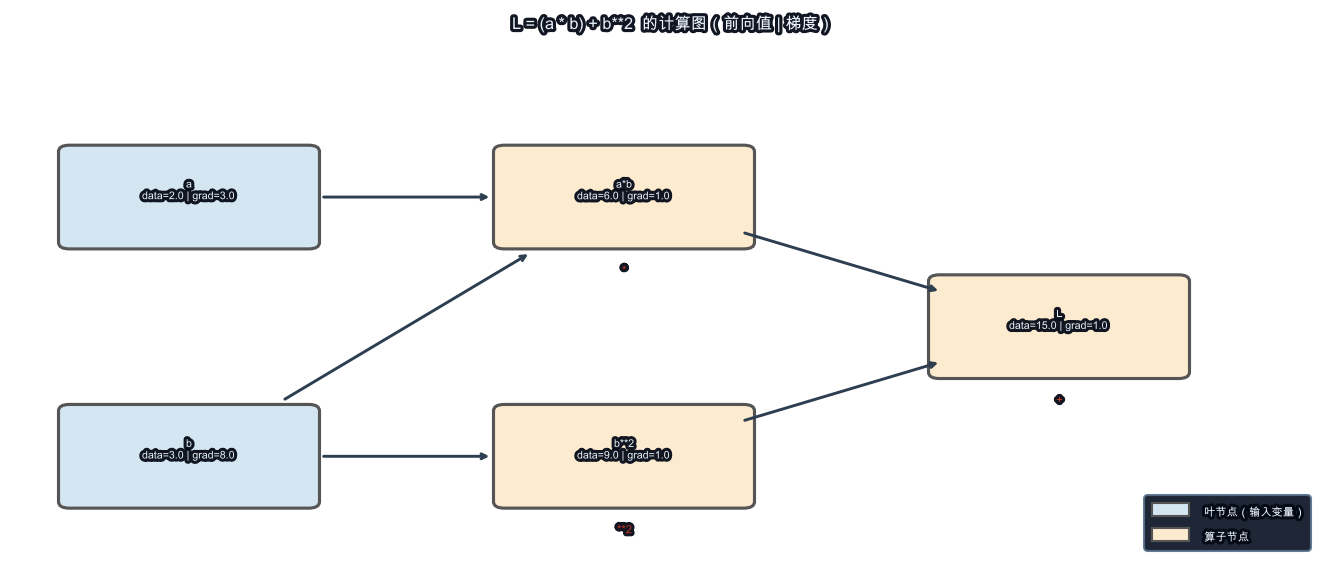

In [3]:
# ── 演示：用 matplotlib 画 Value 计算图的 DAG ──
# 小图：L = (a * b) + b**2，a=2, b=3
# L = 6 + 9 = 15；dL/da = b = 3；dL/db = a + 2b = 2+6 = 8

nodes = {
    'a':    {'data':  2.0, 'grad': 3.0, 'op': ''},
    'b':    {'data':  3.0, 'grad': 8.0, 'op': ''},
    'a*b':  {'data':  6.0, 'grad': 1.0, 'op': '*'},
    'b**2': {'data':  9.0, 'grad': 1.0, 'op': '**2'},
    'L':    {'data': 15.0, 'grad': 1.0, 'op': '+'},
}
edges = [
    ('a',    'a*b'),
    ('b',    'a*b'),
    ('b',    'b**2'),
    ('a*b',  'L'),
    ('b**2', 'L'),
]
pos = {
    'a':    (0, 2),
    'b':    (0, 0),
    'a*b':  (2, 2),
    'b**2': (2, 0),
    'L':    (4, 1),
}

fig, ax = plt.subplots(figsize=(9, 4))
ax.set_xlim(-0.8, 5.2)
ax.set_ylim(-0.8, 3.2)
ax.axis('off')
ax.set_title('L = (a * b) + b**2  的计算图（前向值 | 梯度）', fontsize=13)

BOX_W, BOX_H = 1.1, 0.7
leaf_color = '#d4e6f1'
op_color   = '#fdebd0'
for name, (x, y) in pos.items():
    is_leaf = nodes[name]['op'] == ''
    fc = leaf_color if is_leaf else op_color
    rect = mpatches.FancyBboxPatch(
        (x - BOX_W/2, y - BOX_H/2), BOX_W, BOX_H,
        boxstyle='round,pad=0.05', facecolor=fc, edgecolor='#555', linewidth=1.5
    )
    ax.add_patch(rect)
    d  = nodes[name]['data']
    g  = nodes[name]['grad']
    op = nodes[name]['op']
    label = f'{name}\ndata={d:.1f} | grad={g:.1f}'
    ax.text(x, y + 0.05, label, ha='center', va='center', fontsize=8.5)
    if op:
        ax.text(x, y - BOX_H/2 - 0.18, op, ha='center', va='top',
                fontsize=9, color='#c0392b', fontweight='bold')

for src, dst in edges:
    x0, y0 = pos[src]
    x1, y1 = pos[dst]
    dx, dy = x1 - x0, y1 - y0
    shrink = BOX_W / 2 + 0.05
    length = (dx**2 + dy**2) ** 0.5
    ux, uy = dx / length, dy / length
    ax.annotate('',
        xy=(x1 - ux * shrink, y1 - uy * shrink),
        xytext=(x0 + ux * shrink, y0 + uy * shrink),
        arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=1.4)
    )

# 图例句柄：Patch 是抽象基类，不能 add_patch 到坐标轴，
# 直接作为 handles 传给 legend 即可渲染色块。
legend_handles = [
    mpatches.Patch(facecolor=leaf_color, edgecolor='#555', label='叶节点（输入变量）'),
    mpatches.Patch(facecolor=op_color,  edgecolor='#555', label='算子节点'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()
print('✅ DAG 图绘制完成；蓝色=叶节点，橙色=算子节点；grad 已由 backward() 填入')

### 🔍 梯度反向传播的逐步计算——链式法则拆解

上面的 DAG 图显示 $\frac{\partial L}{\partial a} = 3$ 和 $\frac{\partial L}{\partial b} = 8$，这些数字是怎么算出来的？

**核心原理**：反向传播沿着 `_prev` 反向遍历 DAG，用**链式法则**（chain rule）逐步累积梯度。

#### 例子：$L = (a \times b) + b^2$，其中 $a=2, b=3$

**前向计算**（记录 data）：
```
中间值  c = a * b  = 2 * 3 = 6
中间值  d = b**2   = 3**2 = 9
最终值  L = c + d  = 6 + 9 = 15
```

**反向传播**（从 $\frac{\partial L}{\partial L} = 1$ 开始）：

**第一步**：Loss → $c$ 和 $d$ 的梯度

$$\frac{\partial L}{\partial c} = \frac{\partial L}{\partial L} \times \frac{\partial L}{\partial c} = 1 \times 1 = 1 \quad \text{（因为 $L = c + d$，$\frac{\partial L}{\partial c} = 1$）}$$

$$\frac{\partial L}{\partial d} = \frac{\partial L}{\partial L} \times \frac{\partial L}{\partial d} = 1 \times 1 = 1 \quad \text{（加法对每项导数都是 1）}$$

**第二步**：$\frac{\partial L}{\partial c}$ 反向到 $a$ 和 $b$（通过乘法）

$$\frac{\partial L}{\partial a} = \frac{\partial L}{\partial c} \times \frac{\partial c}{\partial a} = 1 \times b = 1 \times 3 = 3 \quad \text{（乘法链式法则：$\frac{\partial (a \times b)}{\partial a} = b$）}$$

$$\frac{\partial L}{\partial b}\big|_{\text{via }c} = \frac{\partial L}{\partial c} \times \frac{\partial c}{\partial b} = 1 \times a = 1 \times 2 = 2$$

**第三步**：$\frac{\partial L}{\partial d}$ 反向到 $b$（通过平方）

$$\frac{\partial L}{\partial b}\big|_{\text{via }d} = \frac{\partial L}{\partial d} \times \frac{\partial d}{\partial b} = 1 \times 2b = 1 \times 2 \times 3 = 6 \quad \text{（幂法则：$\frac{\partial (b^2)}{\partial b} = 2b$）}$$

**第四步**：$\frac{\partial L}{\partial b}$ 来自两条路径，相加

$$\frac{\partial L}{\partial b} = \frac{\partial L}{\partial b}\big|_{\text{via }c} + \frac{\partial L}{\partial b}\big|_{\text{via }d} = 2 + 6 = 8$$

---

**总结**：
- **叶节点** $a, b$ 的梯度 = 所有经过它的路径的偏导数乘积，再相加
- **算子节点**（如 $c, d$）的梯度 = 从输出流向它的梯度
- 代码中 `Value.backward()` 正是这个链式法则的自动化实现



## 2. 损失曲线：识别过拟合（overfitting）的早期信号

训练过程中最重要的两条曲线：

- `train_loss`：模型在训练集上的均方误差（或交叉熵），**应该单调下降**
- `val_loss`：在验证集上的同一指标，**初期跟随下降，过拟合后开始上翘**

两者的差距叫**泛化间隔**（generalization gap）：

```
gap(epoch) = val_loss(epoch) - train_loss(epoch)
```

**早期停止（early stopping）的信号**：当 `val_loss` 连续 `patience` 个 epoch 没有下降时，认为过拟合已开始，停止训练并取验证最优的权重。

对于关键词识别（KeywordCNN），过拟合常见原因：
- 训练集声学环境单一，验证集有噪声
- 模型容量（卷积（convolution）核数）远大于训练样本量
- Mel 特征维度（`n_mels=40`）相对样本数过高

### 🎢 下面那条 Loss 曲线是怎么"编"出来的？—— 拆解公式里的每一项

在看下面的代码之前，先想象一个更熟悉的场景：**骑自行车下坡**。刚出发时坡很陡，你几乎不用蹬车，速度蹭蹭往上涨；可越往下骑，坡度越缓，速度的**增量**也越来越小，最后骑到平地，速度就不再变化了。真实神经网络的训练 loss 曲线，形状上和这个很像——刚开始参数离最优点很远，随便一步梯度下降都能把 loss 砍掉一大截；越接近最优点，能再压低的空间越小，进步越来越慢。

数学上，"下降速度正比于当前剩余量"这种现象，标准的写法就是**指数衰减**：$y = y_0 \cdot e^{-kt}$（$k$ 越大，衰减越快）。这也是为什么下面这行代码长这样：

```python
train_loss = 1.0 * np.exp(-0.08 * epochs) + 0.05 + 0.01 * np.random.randn(60)
```

逐项拆开看：

- **`1.0 * np.exp(-0.08 * epochs)`** —— 这是"越来越慢的下降"本身。`1.0` 是初始 loss 的大致量级（第一个 epoch 时模型几乎是瞎猜）；`0.08` 是我们自己编的一个"衰减速度"，数值越大曲线降得越快。**它不对应任何真实模型的学习率**，只是为了让 60 个 epoch 内的曲线形状看起来像典型的训练曲线——如果你把 0.08 换成 0.2，会看到曲线在前几个 epoch 就迅速趴平。
- **`+ 0.05`** —— 这是曲线最终会趋近、但**永远降不到 0** 的"地板"。真实训练里，loss 不可能归零：数据本身有噪声、有些样本本来就有歧义（比如背景噪音很大的语音样本），这个降不下去的下限有个专门的名字，叫**不可约误差（irreducible error）**。这里的 `0.05` 只是我们随手设的一个示意值。
- **`+ 0.01 * np.random.randn(60)`** —— 这是**训练本身的随机抖动**。真实训练不是一次性看完全部数据再更新参数，而是每次抽一小批（mini-batch）估计梯度方向，这个估计天然带噪声，所以哪怕模型在稳步变好，loss 曲线也不会是一条光滑的下降线，而是"整体向下、局部抖动"。`np.random.randn(60)` 生成 60 个随机抖动量，`0.01` 控制抖动的幅度。
- **`np.random.seed(42)`**（在这段代码最上面）——固定随机数种子，保证你每次重新运行，抖动的具体数值都完全一样，方便对照和调试。

`val_loss` 的构造思路完全一样（也是"指数衰减 + 地板 + 噪声"），只是额外加了一项 `overfit = np.where(epochs > 25, 0.006 * (epochs - 25), 0.0)`——从第 25 个 epoch 开始线性增加，用来模拟"模型开始记住训练集、在验证集上掉头往上走"的过拟合现象。

**划重点**：这整段代码生成的是**编出来的玩具数据（toy data）**，不是任何一次真实训练的日志，目的是让你在一张图上看清"典型的过拟合曲线长什么样"。等你在 Aurora 里跑真实的 `KeywordCNN` 训练时，`train_loss`/`val_loss` 会是训练循环里实际记录下来的数字列表，直接 `plt.plot()` 画出来即可，不需要也不会用这种指数公式去拟合。


✅ best epoch = 41
   val_loss_min  = 0.3535
   泛化间隔 gap  = 0.2585
   → 紫色区域越大，过拟合越严重；早停在绿线处保存最优权重


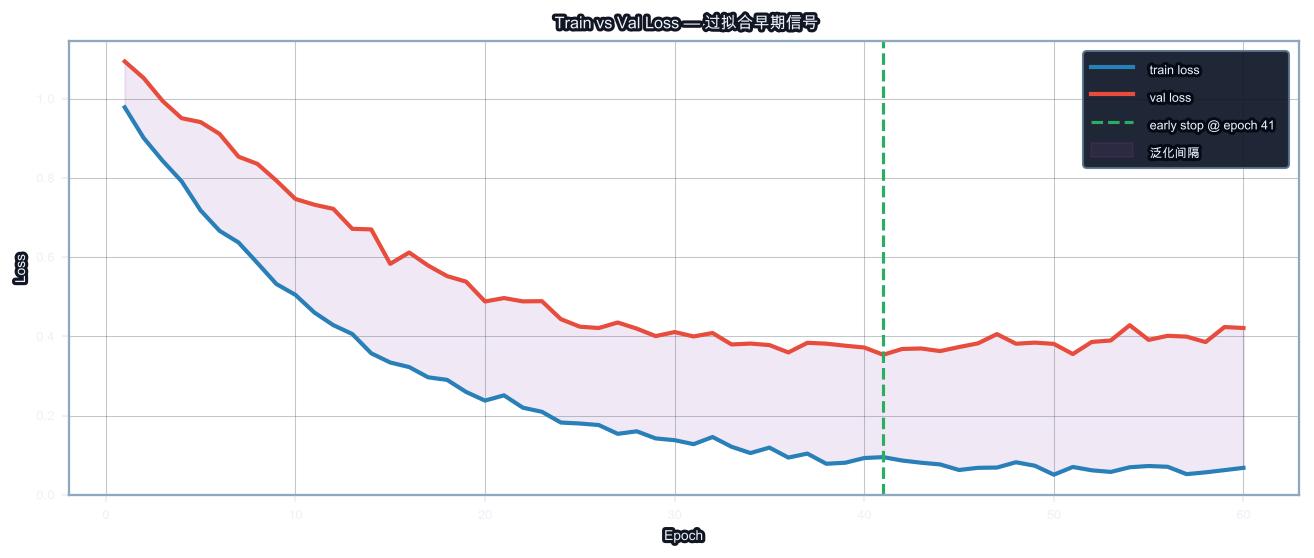

In [4]:
# ── 演示：生成典型的 train/val loss 曲线（含过拟合阶段）──
np.random.seed(42)
epochs = np.arange(1, 61)

train_loss = 1.0 * np.exp(-0.08 * epochs) + 0.05 + 0.01 * np.random.randn(60)
val_decay  = 1.0 * np.exp(-0.05 * epochs) + 0.15
overfit    = np.where(epochs > 25, 0.006 * (epochs - 25), 0.0)
val_loss   = val_decay + overfit + 0.015 * np.random.randn(60)

best_epoch = int(np.argmin(val_loss)) + 1

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs, train_loss, label='train loss', color='#2980b9', lw=2)
ax.plot(epochs, val_loss,   label='val loss',   color='#e74c3c', lw=2)
ax.axvline(best_epoch, color='#27ae60', ls='--', lw=1.5,
           label=f'early stop @ epoch {best_epoch}')
ax.fill_between(epochs,
    np.minimum(train_loss, val_loss),
    np.maximum(train_loss, val_loss),
    alpha=0.12, color='#8e44ad', label='泛化间隔')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Train vs Val Loss — 过拟合早期信号', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

gap_at_best = val_loss[best_epoch-1] - train_loss[best_epoch-1]
print(f'✅ best epoch = {best_epoch}')
print(f'   val_loss_min  = {val_loss[best_epoch-1]:.4f}')
print(f'   泛化间隔 gap  = {gap_at_best:.4f}')
print('   → 紫色区域越大，过拟合越严重；早停在绿线处保存最优权重')

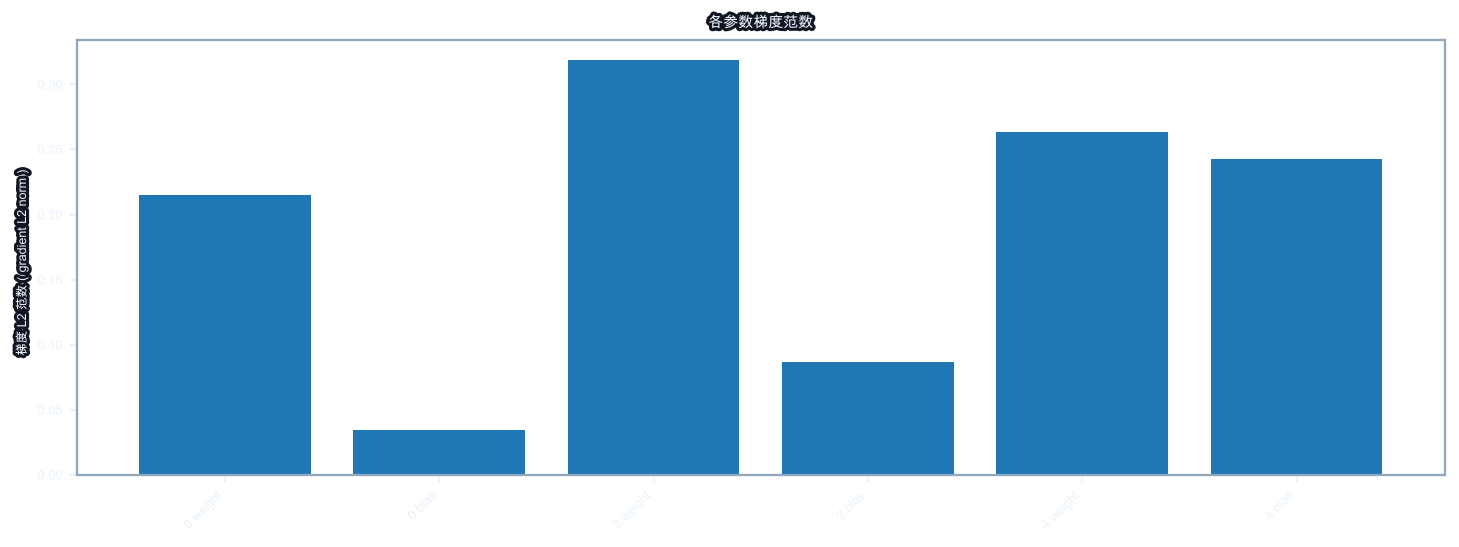

In [5]:
# 可视化梯度范数（gradient norm visualization）
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 演示：定义小型模型，运行一次前向 + 反向，填充梯度
model = nn.Sequential(
    nn.Linear(40, 64), nn.ReLU(),
    nn.Linear(64, 32), nn.ReLU(),
    nn.Linear(32, 10)
)
x_demo = torch.randn(16, 40)
y_demo = torch.randint(0, 10, (16,))
loss = nn.CrossEntropyLoss()(model(x_demo), y_demo)
loss.backward()

grad_norms = []
for name, param in model.named_parameters():
    if param.grad is not None:
        grad_norms.append((name, param.grad.norm().item()))

names = [n for n, _ in grad_norms]  # 使用完整参数路径，区分不同层
norms = [v for _, v in grad_norms]

plt.figure(figsize=(10, 4))
plt.bar(range(len(norms)), norms)
plt.xticks(range(len(names)), names, rotation=45, ha='right')
plt.ylabel('梯度 L2 范数（gradient L2 norm）')
plt.title('各参数梯度范数')
plt.tight_layout()
plt.show()

### 梯度范数的诊断标准 — 如何判断爆炸/消失/健康

梯度 L2 范数（L2 norm）是**该参数所有梯度元素的平方和的平方根**：

$$\|\nabla\theta\|_2 = \sqrt{\sum_i (\partial L / \partial \theta_i)^2}$$

这个标量直接反映了该参数层收到的"梯度信号强度"。不同的范数值有不同的诊断意义：

| 梯度范数范围 | 诊断 | 现象与后果 | 调整建议 |
|-----------|------|---------|--------|
| **< 0.0001** | 🔴 梯度消失（Vanishing） | 梯度太小，参数基本不更新 | • 减小学习率 <br> • 检查激活函数（ReLU/Sigmoid/Tanh） <br> • 用残差连接（residual）或批归一化（batch norm） |
| **0.0001 ~ 0.01** | 🟡 梯度较弱 | 学习缓慢，收敛时间长 | • 增大学习率 <br> • 检查数据预处理（归一化） |
| **0.01 ~ 1.0** | 🟢 梯度健康 | 典型的正常训练范围 | 保持当前设置 |
| **1.0 ~ 10** | 🟡 梯度较强 | 学习可能快速但不稳定 | • 减小学习率 <br> • 加梯度裁剪（gradient clipping） <br> • 增加正则化（dropout/L2） |
| **> 10** | 🔴 梯度爆炸（Exploding） | 参数更新幅度过大，损失震荡或发散 | • 立即减小学习率 <br> • 启用梯度裁剪：`torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)` <br> • 检查激活函数是否饱和 |

#### 现实中的判断方法

通常在训练早期（前 5 个 epoch）观察梯度范数的分布：

1. **正常情况**：各层梯度范数在 0.001 ~ 1.0 之间，稳定或缓慢变化
2. **梯度消失信号**：深层（早期卷积层）的梯度范数逐渐逼近 0，而浅层（输出层附近）的范数仍 > 0.1
3. **梯度爆炸信号**：某一层的梯度范数突然跳到 100+，损失函数同时出现 NaN 或 Inf

#### 代码示例：监控梯度范数

```python
for batch_idx, (x, y) in enumerate(train_loader):
    logits = model(x)
    loss = criterion(logits, y)
    loss.backward()
    
    # 检查梯度范数
    for name, param in model.named_parameters():
        if param.grad is not None:
            norm = param.grad.norm().item()
            if norm > 10:
                print(f"⚠️  {name} 梯度爆炸：{norm:.2f}")
            elif norm < 1e-5:
                print(f"⚠️  {name} 梯度消失：{norm:.2e}")
    
    optimizer.step()
    optimizer.zero_grad()
```



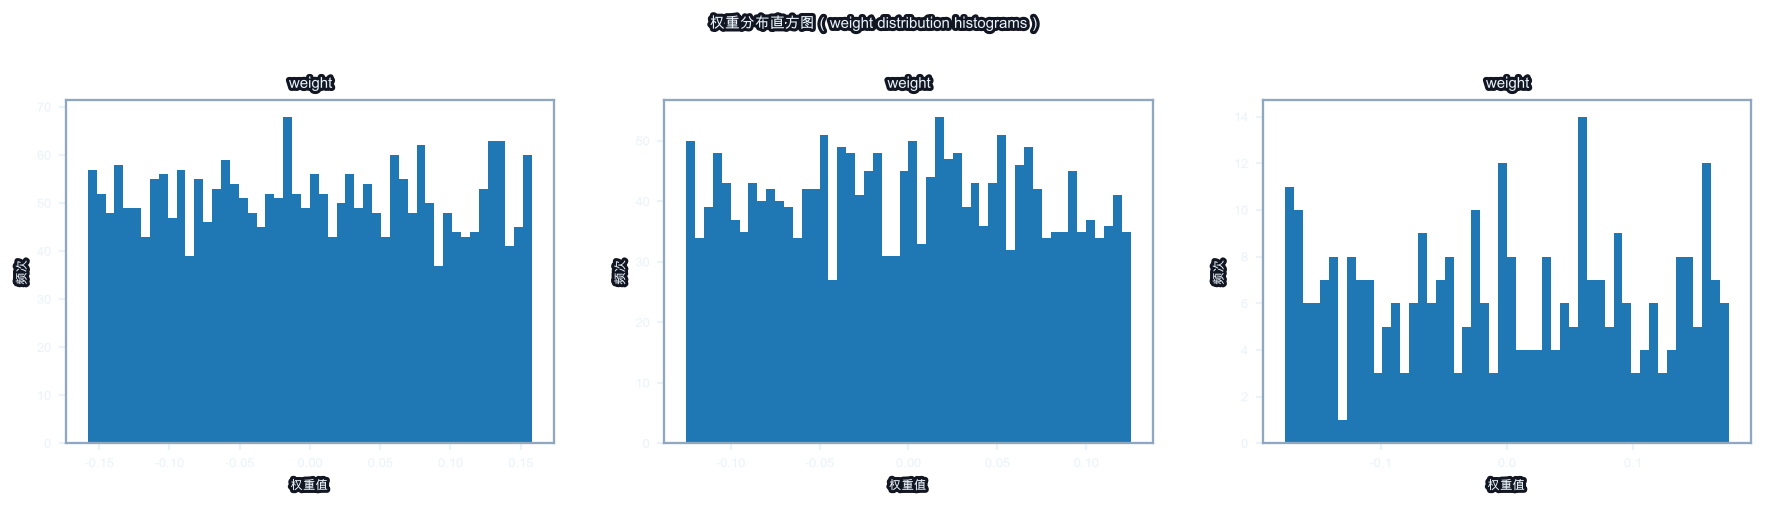

In [6]:
# 可视化权重分布（weight distribution histograms）
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

params_to_plot = [(name, param) for name, param in model.named_parameters() 
                  if param.requires_grad and param.dim() >= 2][:6]

for i, (name, param) in enumerate(params_to_plot):
    axes[i].hist(param.detach().cpu().numpy().flatten(), bins=50, edgecolor='none')
    axes[i].set_title(name.split('.')[-1])
    axes[i].set_xlabel('权重值')
    axes[i].set_ylabel('频次')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('权重分布直方图（weight distribution histograms）')
plt.tight_layout()
plt.show()

## ✏️ 练习：实现 early_stopping()

给定验证集损失列表和 patience 参数，找到**触发早停的 epoch**（从 1 开始计数）。

规则：当最近连续 `patience` 个 epoch 的 val_loss 都**高于**当前最小值时，返回当前最小值对应的 epoch 编号（最优 epoch）。

提示：用一个变量追踪历史最小值和计数器。


### 早停逻辑详解：状态转换表

理解 early stopping 的关键是追踪**两个变量**的变化：
1. `best_loss`：历史上见过的最小 val_loss
2. `no_improve`：连续没有改善的 epoch 计数

**规则**：
- 当 `loss < best_loss` 时，发现新的最优值 → 更新 `best_loss` 和 `best_epoch`，**重置** `no_improve=0`
- 当 `loss >= best_loss` 时，没有改善 → **递增** `no_improve += 1`
- 当 `no_improve >= patience` 时，触发早停 → **返回** `best_epoch`

**例子 1：losses_a = [0.9, 0.7, 0.5, 0.6, 0.65, 0.7, 0.72, 0.75]，patience=3**

| epoch | val_loss | best_loss | 是否改善 | no_improve | 动作 | 返回值 |
|-------|----------|-----------|---------|-----------|------|--------|
| 1 | 0.90 | ∞ | ✓ 新最小 | 0 | 更新best_epoch=1 | — |
| 2 | 0.70 | 0.90 | ✓ 新最小 | 0 | 更新best_epoch=2 | — |
| 3 | 0.50 | 0.70 | ✓ 新最小 | 0 | 更新best_epoch=3 | — |
| 4 | 0.60 | 0.50 | ✗ 无改善 | 1 | 继续 | — |
| 5 | 0.65 | 0.50 | ✗ 无改善 | 2 | 继续 | — |
| 6 | 0.70 | 0.50 | ✗ 无改善 | 3 | no_improve=3 ≥ patience | **返回 3** |

→ **在 epoch 6 时触发早停，返回 epoch 3（最优的 epoch）**

**例子 2：losses_b = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4]，patience=2**

| epoch | val_loss | best_loss | 是否改善 | no_improve | 动作 |
|-------|----------|-----------|---------|-----------|------|
| 1 | 0.90 | ∞ | ✓ 新最小 | 0 | 更新best_epoch=1 |
| 2 | 0.80 | 0.90 | ✓ 新最小 | 0 | 更新best_epoch=2 |
| 3 | 0.70 | 0.80 | ✓ 新最小 | 0 | 更新best_epoch=3 |
| 4 | 0.60 | 0.70 | ✓ 新最小 | 0 | 更新best_epoch=4 |
| 5 | 0.50 | 0.60 | ✓ 新最小 | 0 | 更新best_epoch=5 |
| 6 | 0.40 | 0.50 | ✓ 新最小 | 0 | 更新best_epoch=6 |

→ **序列一直下降，从不触发，返回 6（最后的最优值）**

**代码框架**：
```python
best_epoch = 1
best_loss  = float('inf')
no_improve = 0
for epoch, loss in enumerate(val_losses, start=1):
    if loss < best_loss:
        best_loss = loss
        best_epoch = epoch
        no_improve = 0          # ← 关键：发现新的最小值时重置
    else:
        no_improve += 1         # ← 关键：没有改善时递增
        if no_improve >= patience:
            return best_epoch   # ← 关键：触发条件
return best_epoch               # ← 兜底：序列结束仍未触发
```



In [7]:
def early_stopping(val_losses: list, patience: int) -> int:
    """
    返回触发早停时的最优 epoch（1-based）。
    若整个序列都没有触发，返回 val_loss 最小的 epoch。

    参数
    ----
    val_losses : list[float]  每个 epoch 的验证集损失
    patience   : int          连续多少个 epoch 无改善则停止

    返回
    ----
    int  最优 epoch 编号（1-based）
    """
    # ── TODO：补全实现 ──
    best_epoch = 1
    best_loss  = float('inf')
    no_improve = 0
    for epoch, loss in enumerate(val_losses, start=1):
        raise NotImplementedError("请删除这行，补全实现")
    return best_epoch


# ── 验证 ──
try:
    losses_a = [0.9, 0.7, 0.5, 0.6, 0.65, 0.7, 0.72, 0.75]  # 从 epoch 3 开始上升，patience=3 → 停在 epoch 3
    result_a = early_stopping(losses_a, patience=3)
    assert result_a == 3, f'期望 3，得到 {result_a}'

    losses_b = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4]  # 一直下降，返回最后一个 epoch
    result_b = early_stopping(losses_b, patience=2)
    assert result_b == 6, f'期望 6，得到 {result_b}'

    losses_c = [1.0, 0.5, 0.6, 0.7, 0.8, 0.9]  # patience=2，epoch 2 最优
    result_c = early_stopping(losses_c, patience=2)
    assert result_c == 2, f'期望 2，得到 {result_c}'

    print('✅ 所有 assert 通过！early_stopping() 实现正确。')
    print(f'   losses_a(patience=3) → best_epoch = {result_a}')
    print(f'   losses_b(patience=2) → best_epoch = {result_b}')
    print(f'   losses_c(patience=2) → best_epoch = {result_c}')
except (NotImplementedError, TypeError):
    print('⚠️  请先补全 early_stopping() 中 TODO 部分，再运行验证。')
except AssertionError as e:
    print(f'❌ 验证失败：{e}')
    print('   提示：检查 best_epoch 的更新条件，以及 no_improve 计数器的重置时机。')


⚠️  请先补全 early_stopping() 中 TODO 部分，再运行验证。


## 过渡说明：mel 谱误分类对比

以上三类图——DAG 图、损失曲线、梯度范数 / 权重分布（weight distribution）——已演示了训练过程的调试工具链。
接下来通过**混淆矩阵**和 **mel 谱对比**进一步说明：当模型把 "no" 误判为 "yes" 时，频谱上有哪些具体特征让分类器失误。


### 为什么需要 Mel 频率变换？人耳的频率感知不是线性的

**直观类比**：想象两个音叉。
- 频率从 100Hz → 200Hz，感觉上音高跳变很大
- 频率从 8000Hz → 8100Hz，我们几乎听不出区别

为什么？因为**人耳对低频更敏感，对高频的分辨能力变弱**。如果直接用线性频率轴分析语音，会浪费很多计算资源在高频的细微差别上，而低频的重要信息被"压缩"了。

**Mel 标度**：把频率变换到与人耳感知对应的"Mel"标度，使得相同的 Mel 间隔在感知上是等距的。

$$\text{mel}(f) = 2595 \log_{10}\left(1 + \frac{f}{700}\right)$$

这是一个经验公式（由 Stevens 等人在 1937 年通过人类听觉实验确定的）。几个关键数字的含义：
- **700**：某个参考频率点（单位 Hz）
- **2595**：归一化常数，使得 8000Hz 对应 mel 值为 2592
- **$\log_{10}$**：对数变换使高频被"压扁"

**例子**：
- 80Hz  → mel ≈ $2595 \log_{10}(1 + 80/700) \approx 146$
- 1000Hz → mel ≈ $2595 \log_{10}(1 + 1000/700) \approx 1127$
- 8000Hz → mel ≈ $2595 \log_{10}(1 + 8000/700) \approx 2592$

注意到：80→1000 跨越了 146 mel，而 1000→8000 也只跨越了 1465 mel，尽管频率差异更大。

#### 三角滤波器的设计

在 Mel 标度上，用**等间距的三角形滤波器**采样。每个三角形在其中心频率达峰（响应=1.0），两边线性衰减到 0。为什么？

1. **计算效率**：三角形与频谱的卷积就是直接相加（不涉及昂贵的傅里叶变换）
2. **人耳听觉**：人耳对频率的响应大致是"局部"的，三角形的宽度近似对应一个关键频率范围
3. **特征提取**：三角形的叠加覆盖（neighboring filters overlap）保证了平滑的频率响应，避免信息断裂

**代码逻辑**：
- 在 Mel 轴上均匀分布 `n_mels` 个三角形中心
- 每个三角形的底宽由相邻滤波器决定（互相重叠 ~50%）
- 对频谱做线性插值以确定每个频率点的三角形响应



## 3. 混淆矩阵（Confusion Matrix）— 手工计算与可视化

混淆矩阵 `CM[i, j]` = 真实类别为 `i`、被预测为 `j` 的样本数。
- **对角线**：分类正确；**非对角**：误分类
- **召回率（Recall）** = `CM[i,i] / sum(CM[i,:])` — 该类被正确识别的比例
- **精确率（Precision）** = `CM[i,i] / sum(CM[:,i])` — 预测为该类时真的是该类的比例

下面用 `np.zeros` 手工累积，**不使用 sklearn**。


In [8]:
# ── 小例子：理解 axis=1 和 keepdims 的含义 ──
# 混淆矩阵常见操作：CM.sum(axis=1, keepdims=True) — 按行求和

# 小数字例子
CM_tiny = np.array([
    [15,  0,  1],  # 第 0 行：真实类0的分布（15个对，0个分成1，1个分成2）
    [ 2, 18,  0],  # 第 1 行：真实类1的分布（2个分成0，18个对，0个分成2）
    [ 0,  1, 19],  # 第 2 行：真实类2的分布（0个分成0，1个分成1，19个对）
])

print('原矩阵 CM_tiny（3行3列）：')
print(CM_tiny)
print(f'形状：{CM_tiny.shape}\n')

# axis=1 表示沿着列方向相加（即对每一行求和）
row_sums = CM_tiny.sum(axis=1)
print('CM.sum(axis=1) — 沿列相加（=对每行求和）：')
print(f'{row_sums}  形状={row_sums.shape}')
print('  → [15+0+1=16, 2+18+0=20, 0+1+19=20]\n')

# keepdims=True 保留轴的维度（即行列都保留，只是相加的维度变成 1）
row_sums_2d = CM_tiny.sum(axis=1, keepdims=True)
print('CM.sum(axis=1, keepdims=True) — 结果保持 2D 形状（3行1列）：')
print(row_sums_2d)
print(f'形状：{row_sums_2d.shape}\n')

# 行归一化：每行除以该行的总和
CM_norm = CM_tiny.astype(float) / row_sums_2d
print('行归一化（除以行和）：')
print(CM_norm)
print('每一行的和都是 1.0（即每行是该类的概率分布）\n')

print('✅ 关键概念：')
print('  · axis=1 = 沿列方向操作 = 对每一行的元素聚合')
print('  · axis=0 = 沿行方向操作 = 对每一列的元素聚合')
print('  · keepdims=True 保持维度数（2D→2D），方便广播')


原矩阵 CM_tiny（3行3列）：
[[15  0  1]
 [ 2 18  0]
 [ 0  1 19]]
形状：(3, 3)

CM.sum(axis=1) — 沿列相加（=对每行求和）：
[16 20 20]  形状=(3,)
  → [15+0+1=16, 2+18+0=20, 0+1+19=20]

CM.sum(axis=1, keepdims=True) — 结果保持 2D 形状（3行1列）：
[[16]
 [20]
 [20]]
形状：(3, 1)

行归一化（除以行和）：
[[0.9375 0.     0.0625]
 [0.1    0.9    0.    ]
 [0.     0.05   0.95  ]]
每一行的和都是 1.0（即每行是该类的概率分布）

✅ 关键概念：
  · axis=1 = 沿列方向操作 = 对每一行的元素聚合
  · axis=0 = 沿行方向操作 = 对每一列的元素聚合
  · keepdims=True 保持维度数（2D→2D），方便广播


📊 各类 Recall / Precision:
   yes     recall=0.88  precision=0.79
   no      recall=0.76  precision=0.93
   up      recall=1.00  precision=1.00
   down    recall=0.90  precision=0.90
   left    recall=0.94  precision=0.84
   right   recall=0.91  precision=0.91
   on      recall=0.94  precision=0.89
   off     recall=0.96  precision=0.96
   stop    recall=0.94  precision=0.94
   go      recall=0.83  precision=0.95

✅ CM["no","yes"] 特别高 → 说明"no"频繁被误判为"yes"
   → 结合下方 mel 谱对比可定位根因：鼻音区能量不足时频谱与"yes"相似

📖 什么时候看行（召回率），什么时候看列（精确率）？
   · 关心"这个类别本该出现的样本，有多少被找出来了" → 看行（Recall）
     例：语音助手的唤醒词"stop"如果没被识别（漏检），代价很高，就该盯着
     "stop" 这一行的召回率——它衡量"真的说了 stop 的样本，模型找回了多少"
   · 关心"模型一旦做出这个预测，可信度有多高" → 看列（Precision）
     例：智能家居里模型一旦预测"go"就会真的执行动作，如果这个预测经常是
     错的（把别的词误认成 go），就该盯着 "go" 这一列的精确率
   · 回到"no 被误判为 yes"这件事，两个视角讲的是两件不同的事：
     - 看"no"这一行 → no 的召回率偏低（该被认出的 no，有 30% 漏掉了）
     - 看"yes"这一列 → yes 的精确率会被拉低（很多假的 no 混进了 yes 的
       预测堆里，模型说"是 yes"时，可信度打了折扣）


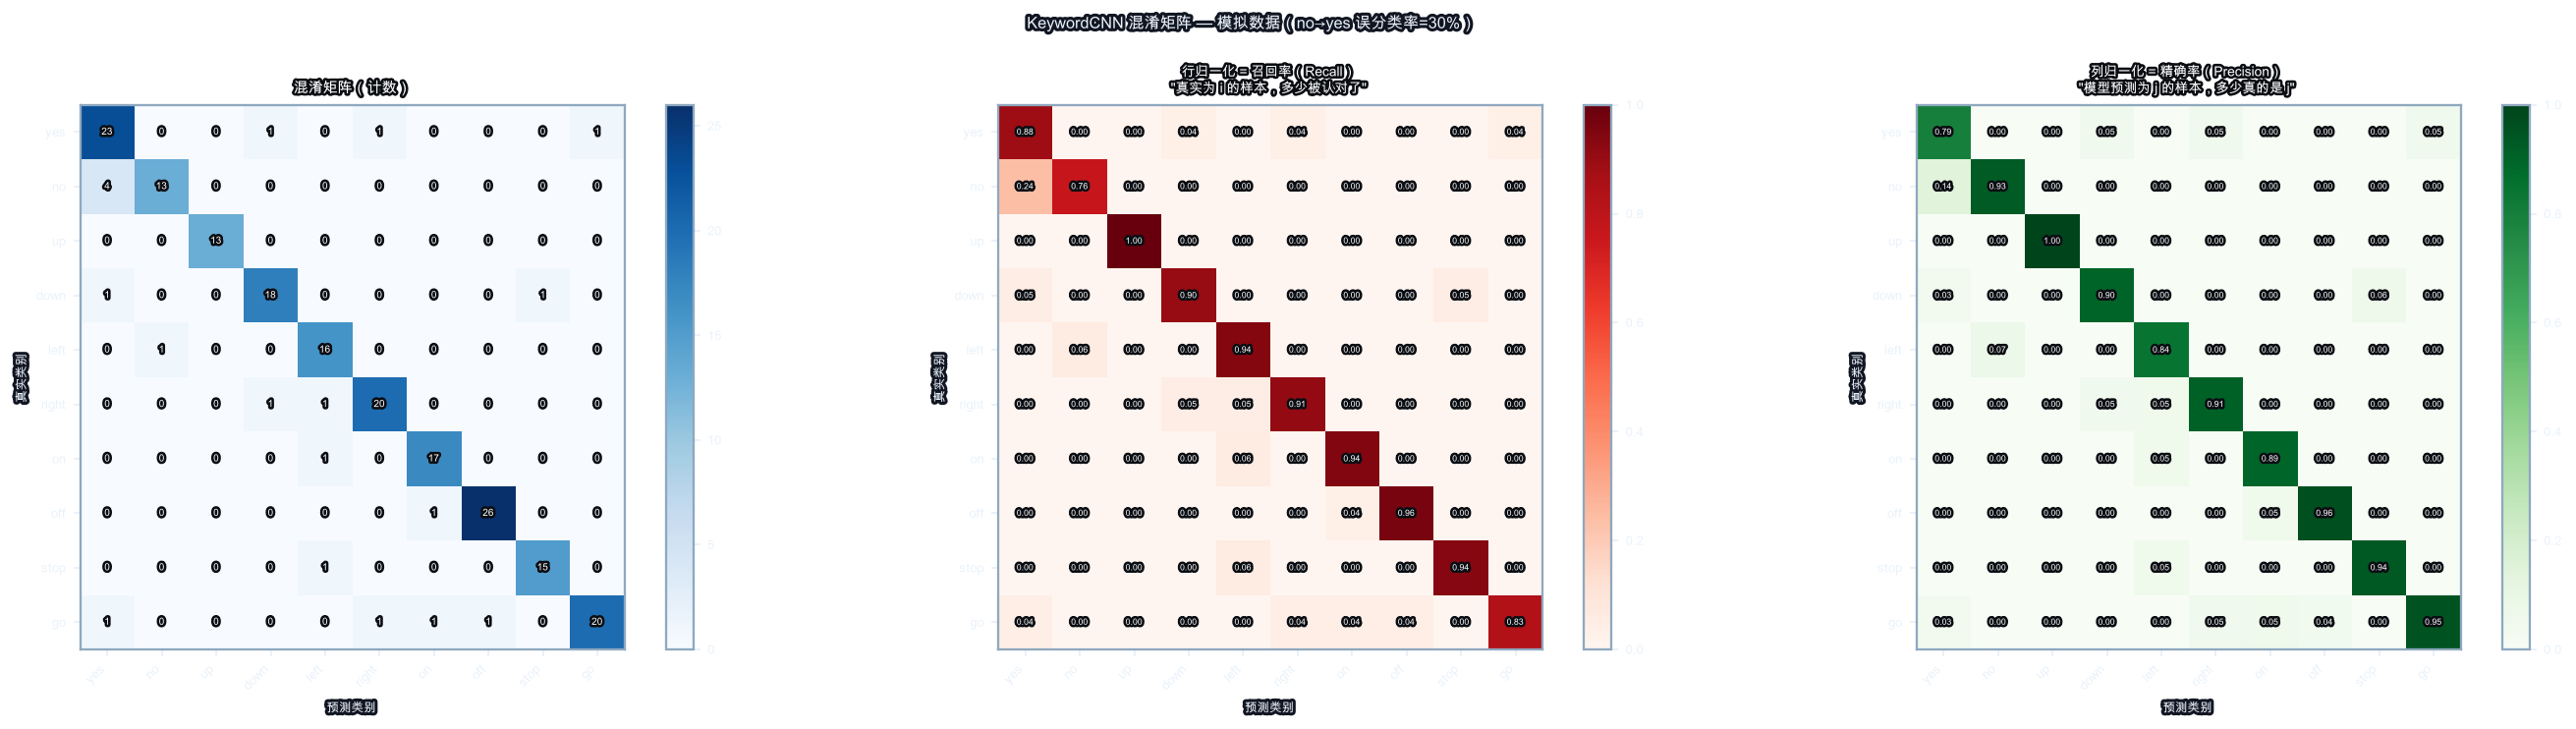

In [9]:
# ── 混淆矩阵：手工计算（np only）+ imshow 可视化 ──
# 模拟 10 类关键词分类器在 200 个测试样本上的预测结果
np.random.seed(7)
CLASSES = ['yes','no','up','down','left','right','on','off','stop','go']
N_CLASSES = len(CLASSES)
N_SAMPLES = 200

y_true = np.random.randint(0, N_CLASSES, N_SAMPLES)
# 给分类器加入系统性混淆：'no'(1) 有 30% 概率被误判为 'yes'(0)
y_pred = y_true.copy()
for idx in range(N_SAMPLES):
    if y_true[idx] == 1 and np.random.rand() < 0.30:
        y_pred[idx] = 0  # no → yes 误分类
    elif y_true[idx] != 1 and np.random.rand() < 0.10:
        y_pred[idx] = np.random.randint(0, N_CLASSES)

# 手工累积混淆矩阵
CM = np.zeros((N_CLASSES, N_CLASSES), dtype=int)
for t, p in zip(y_true, y_pred):
    CM[t, p] += 1

# 行归一化：每一行除以该行的总和 → 每个格子变成"真实类别 i 的样本里，
# 有多少比例被预测成 j"——这是 召回率（Recall）视角，行内加总=1
CM_norm_row = CM.astype(float) / (CM.sum(axis=1, keepdims=True) + 1e-9)

# 列归一化：每一列除以该列的总和 → 每个格子变成"模型预测为 j 的样本里，
# 有多少比例真实类别是 i"——这是 精确率（Precision）视角，列内加总=1
CM_norm_col = CM.astype(float) / (CM.sum(axis=0, keepdims=True) + 1e-9)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# 左：计数矩阵
im0 = axes[0].imshow(CM, cmap='Blues')
axes[0].set_title('混淆矩阵（计数）', fontsize=12)
axes[0].set_xticks(range(N_CLASSES)); axes[0].set_xticklabels(CLASSES, rotation=45, ha='right')
axes[0].set_yticks(range(N_CLASSES)); axes[0].set_yticklabels(CLASSES)
axes[0].set_xlabel('预测类别'); axes[0].set_ylabel('真实类别')
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        axes[0].text(j, i, CM[i,j], ha='center', va='center', fontsize=8,
                     color='white' if CM[i,j] > CM.max()*0.6 else 'black')
plt.colorbar(im0, ax=axes[0])

# 中：行归一化矩阵（召回率视角）—— 沿着"一行"看：这个真实类别的样本都去哪了
im1 = axes[1].imshow(CM_norm_row, cmap='Reds', vmin=0, vmax=1)
axes[1].set_title('行归一化 = 召回率（Recall）\n"真实为 i 的样本，多少被认对了"', fontsize=11)
axes[1].set_xticks(range(N_CLASSES)); axes[1].set_xticklabels(CLASSES, rotation=45, ha='right')
axes[1].set_yticks(range(N_CLASSES)); axes[1].set_yticklabels(CLASSES)
axes[1].set_xlabel('预测类别'); axes[1].set_ylabel('真实类别')
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        axes[1].text(j, i, f'{CM_norm_row[i,j]:.2f}', ha='center', va='center', fontsize=7,
                     color='white' if CM_norm_row[i,j] > 0.6 else 'black')
plt.colorbar(im1, ax=axes[1])

# 右：列归一化矩阵（精确率视角）—— 沿着"一列"看：模型喊出 j 时，喊对了多少
im2 = axes[2].imshow(CM_norm_col, cmap='Greens', vmin=0, vmax=1)
axes[2].set_title('列归一化 = 精确率（Precision）\n"模型预测为 j 的样本，多少真的是 j"', fontsize=11)
axes[2].set_xticks(range(N_CLASSES)); axes[2].set_xticklabels(CLASSES, rotation=45, ha='right')
axes[2].set_yticks(range(N_CLASSES)); axes[2].set_yticklabels(CLASSES)
axes[2].set_xlabel('预测类别'); axes[2].set_ylabel('真实类别')
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        axes[2].text(j, i, f'{CM_norm_col[i,j]:.2f}', ha='center', va='center', fontsize=7,
                     color='white' if CM_norm_col[i,j] > 0.6 else 'black')
plt.colorbar(im2, ax=axes[2])

plt.suptitle('KeywordCNN 混淆矩阵 — 模拟数据（no→yes 误分类率=30%）', fontsize=13)
plt.tight_layout()
plt.show()

# 打印 recall 和 precision
recall    = np.diag(CM) / (CM.sum(axis=1) + 1e-9)
precision = np.diag(CM) / (CM.sum(axis=0) + 1e-9)
print('📊 各类 Recall / Precision:')
for c, r, p in zip(CLASSES, recall, precision):
    print(f'   {c:6s}  recall={r:.2f}  precision={p:.2f}')
print()
print('✅ CM["no","yes"] 特别高 → 说明"no"频繁被误判为"yes"')
print('   → 结合下方 mel 谱对比可定位根因：鼻音区能量不足时频谱与"yes"相似')
print()
print('📖 什么时候看行（召回率），什么时候看列（精确率）？')
print('   · 关心"这个类别本该出现的样本，有多少被找出来了" → 看行（Recall）')
print('     例：语音助手的唤醒词"stop"如果没被识别（漏检），代价很高，就该盯着')
print('     "stop" 这一行的召回率——它衡量"真的说了 stop 的样本，模型找回了多少"')
print('   · 关心"模型一旦做出这个预测，可信度有多高" → 看列（Precision）')
print('     例：智能家居里模型一旦预测"go"就会真的执行动作，如果这个预测经常是')
print('     错的（把别的词误认成 go），就该盯着 "go" 这一列的精确率')
print('   · 回到"no 被误判为 yes"这件事，两个视角讲的是两件不同的事：')
print('     - 看"no"这一行 → no 的召回率偏低（该被认出的 no，有 30% 漏掉了）')
print('     - 看"yes"这一列 → yes 的精确率会被拉低（很多假的 no 混进了 yes 的')
print('       预测堆里，模型说"是 yes"时，可信度打了折扣）')


✅ 观察要点：
  · 正确 yes（蓝）：高频滤波器（上方）有明显能量条带
  · 正确 no（绿）：低频滤波器（下方）有鼻音能量
  · 误分类 no（红）：低频鼻音消失，高频条带出现 → 与 yes 高度相似
  · 将 N_MELS 从 40 改为 80，可观察频率分辨率提升对区分度的影响


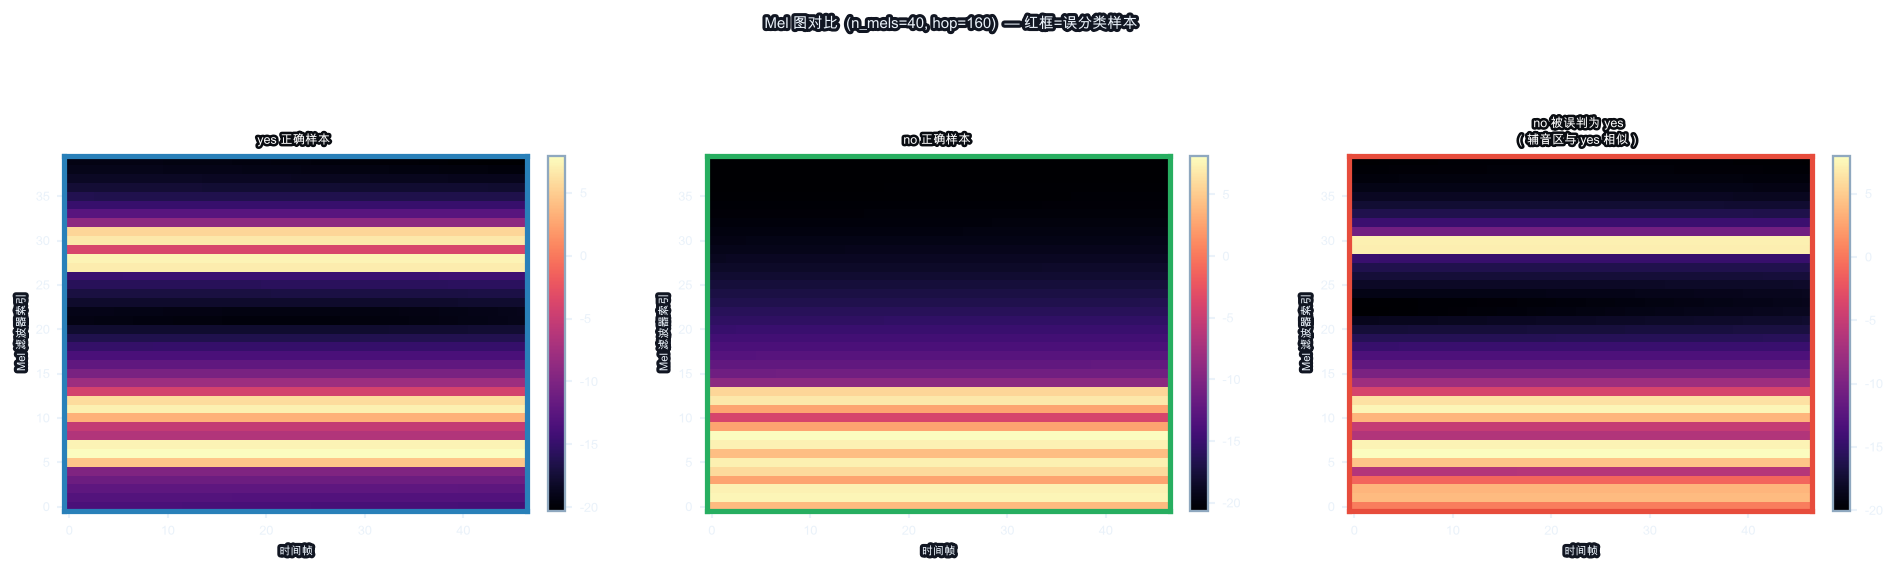

In [10]:
# ── 参数实验：合成关键词 mel 图，模拟误分类对比 ──
# 不依赖真实音频；用正弦叠加模拟 yes/no 的粗略频谱特征

SR = 16000
N_MELS = 40      # ✏️ 尝试 20 / 40 / 80，观察频率分辨率变化
HOP    = 160     # ✏️ 尝试 80 / 160 / 320，观察时间分辨率变化
N      = int(SR * 0.5)  # 0.5 秒

def synth_keyword(freqs, amps, n=N, sr=SR):
    t = np.linspace(0, n / sr, n)
    sig = sum(a * np.sin(2 * np.pi * f * t) for f, a in zip(freqs, amps))
    return sig / (np.abs(sig).max() + 1e-9)

def naive_mel(sig, sr=SR, n_mels=N_MELS, hop=HOP, n_fft=512):
    frames = [sig[i:i+n_fft] * np.hanning(n_fft)
              for i in range(0, len(sig) - n_fft, hop)]
    specs  = np.array([np.abs(np.fft.rfft(f))**2 for f in frames]).T
    freq_bins = np.linspace(0, sr/2, n_fft//2 + 1)
    mel_low  = 2595 * np.log10(1 + 80   / 700)
    mel_high = 2595 * np.log10(1 + 8000 / 700)
    mel_pts  = np.linspace(mel_low, mel_high, n_mels + 2)
    hz_pts   = 700 * (10 ** (mel_pts / 2595) - 1)
    fb = np.zeros((n_mels, n_fft//2 + 1))
    for m in range(1, n_mels + 1):
        f0, f1, f2 = hz_pts[m-1], hz_pts[m], hz_pts[m+1]
        for k, f in enumerate(freq_bins):
            if f0 <= f < f1:  fb[m-1, k] = (f - f0) / (f1 - f0 + 1e-12)
            elif f1 <= f <= f2: fb[m-1, k] = (f2 - f) / (f2 - f1 + 1e-12)
    return np.log(fb @ specs + 1e-9)

# yes：高频辅音 [3500, 4200] + 中频元音 [500, 900]
yes_sig    = synth_keyword([3500, 4200, 500,  900], [0.6, 0.4, 0.8, 0.5])
# no：低频鼻音 [200, 400] + 中频元音 [600, 1000]
no_sig     = synth_keyword([200,  400,  600, 1000], [0.7, 0.5, 0.8, 0.4])
# 误分类的 no 样本：鼻音极弱，高频噪声强，让模型误判为 yes
no_bad_sig = synth_keyword([200,  4000, 500,  900], [0.1, 0.5, 0.7, 0.5])

mel_yes    = naive_mel(yes_sig)
mel_no     = naive_mel(no_sig)
mel_no_bad = naive_mel(no_bad_sig)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
items = [
    (mel_yes,    'yes 正确样本',         '#2980b9'),
    (mel_no,     'no 正确样本',           '#27ae60'),
    (mel_no_bad, 'no 被误判为 yes\n（辅音区与 yes 相似）', '#e74c3c'),
]
for ax, (mel, title, bc) in zip(axes, items):
    im = ax.imshow(mel, aspect='auto', origin='lower',
                   cmap='magma', interpolation='nearest')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('时间帧', fontsize=9)
    ax.set_ylabel('Mel 滤波器索引', fontsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor(bc); spine.set_linewidth(2.5)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(
    f'Mel 图对比  (n_mels={N_MELS}, hop={HOP})  — 红框=误分类样本',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

print('✅ 观察要点：')
print('  · 正确 yes（蓝）：高频滤波器（上方）有明显能量条带')
print('  · 正确 no（绿）：低频滤波器（下方）有鼻音能量')
print('  · 误分类 no（红）：低频鼻音消失，高频条带出现 → 与 yes 高度相似')
print(f'  · 将 N_MELS 从 {N_MELS} 改为 80，可观察频率分辨率提升对区分度的影响')

### 🎛 N_MELS 和 HOP 到底该怎么选？—— 从"随便试试"到有原则地选

上面代码的注释只是说"✏️ 尝试 N_MELS=20/40/80""✏️ 尝试 HOP=80/160/320，观察变化"，但没告诉你**该往哪个方向调、为什么这节课固定用 40 和 160**。这里补一份可操作的经验法则。

#### N_MELS：频率方向切成几份

想象你要用马赛克格子去描述一张连续变化的彩虹图。**格子数量（N_MELS）越多**，越能分辨出相邻两种颜色的细微差别（频率分辨率越高）；但格子一旦多到超过图片本身的信息量，每个格子里"能看到的东西"就趋于随机噪声——模型学到的可能不是真正的规律，而是训练集里偶然出现的噪声模式，这就是**过拟合**风险变大的原因。反过来，格子太少，两种本来不同的颜色会被强行归成一类，模型天生就分不清（欠拟合，信息丢失）。

所以判断原则很简单：**数据量和模型容量能撑得起多少格子，就用多少格子**。

| N_MELS | 适用场景 | 例子 |
|---|---|---|
| 20 左右 | 数据量小、任务简单（比如几个关键词的唤醒词识别）、算力有限的嵌入式设备 | 智能音箱唤醒词 |
| 40 | 中等数据量、中等复杂度任务的**平衡点**，业界最常见的默认值 | Kaldi、ESPnet 等语音工具包的常用默认配置；本课的 KeywordCNN |
| 80 甚至更多 | 大规模数据、追求高精度的完整语音识别系统 | OpenAI Whisper 用 80 个 mel 频带 |

这就是本课固定用 `N_MELS = 40` 的原因：这是一个关键词识别任务，数据量不算大也不算小，40 是一个不容易出错的折中选择——你当然可以自己改成 80 试试，但通常会发现验证集准确率提升有限，甚至因为过拟合略微下降。

#### HOP：时间方向每隔多久看一帧

再换一个类比：用相机连续拍照，记录一个人跑步的动作。**两次拍照的间隔（hop）太长**，会漏掉一些关键的中间动作（时间分辨率差，快速的辅音可能整个被"跳过"）；**间隔太短**，则会拍出大量几乎一模一样的照片，浪费存储和计算量却换不来多少新信息。

经验法则：**HOP 通常取 N_FFT 的 1/4**。本课 `N_FFT=512`，所以理论上 `HOP≈128`；代码里实际用的是 `HOP=160`，这是因为在 `SR=16000`（16kHz 采样率）下，160 个采样点正好对应 **10 毫秒**——这是语音处理里一个非常常见的"整数时间"惯例（librosa、Kaldi 等工具包的默认帧移也常年停留在 10ms 左右），比死抠"N_FFT 的整 1/4"更符合语音学上对音素时长的直觉（大多数辅音、元音的稳定段落都在几十毫秒量级，10ms 的采样间隔足够捕捉其变化）。

| 超参数 | 太小的代价 | 太大的代价 | 本课选择 |
|---|---|---|---|
| N_MELS | 频率分辨率不足，相近音素分不清（欠拟合） | 过拟合风险增加，训练变慢 | 40（中等数据量的平衡点） |
| HOP | 计算量暴涨，相邻帧高度重复 | 时间分辨率变差，快速音素被"抹平" | 160（对应 16kHz 下的 10ms，语音处理惯例） |

一句话总结：**这两个超参数都跟着"数据量、任务难度、能不能承受过拟合"走，没有放之四海皆准的固定值——40 和 160 只是这节课这个任务下的一个合理起点，动手改一改、看看验证集准确率怎么变化，就是最好的学习方式。**


### Mel 频谱对比：误分类样本的频域特征

下面演示一个**合成示意图**（synthetic demonstration），用叠加的正弦波模拟 "yes" 和 "no" 的粗略频谱特征，然后用 Mel 滤波器提取。

⚠️ **重要说明**：以下是为了演示**分类错误的可能根源**而设计的合成频率，**不代表真实英文发音**。真实的 "yes" 和 "no" 包含复杂的时变频谱、共振峰（formants）和复杂的辅音，本演示只展示了高度简化的示意。

**演示设计**：
- **"yes" 正确样本**：包含**高频辅音** [3500, 4200 Hz] 和**中频元音** [500, 900 Hz]
  - 高频辅音是英文 /s/ 音的特征
- **"no" 正确样本**：包含**低频鼻音** [200, 400 Hz] 和**中频元音** [600, 1000 Hz]
  - 低频鼻音是 /n/ 音的特征
- **"no" 误分类样本**（被误判为"yes"）：鼻音极弱，**代之以高频噪声** [3500, 4200 Hz]
  - 这模拟了在嘈杂环境中，鼻音被淹没而高频能量突现的情况
  - 结果 Mel 图与 "yes" 相似 → 分类器困惑

#### 追问：为什么偏偏选 [3500, 4200] 和 [200, 400] 这两个频段？是声学事实还是随便定的？

答案是：**既不是精确还原真实发音，也不是随便拍脑袋——是刻意选得"很极端"，为了在图上把差异夸大到一眼就能看出来。** 具体设计逻辑是这样的：

1. **先定一个大方向**：真实语音里，摩擦音（比如 /s/）确实会集中更多能量在中高频，鼻音（比如 /n/）确实会集中更多能量在低频——这是这两个频段选择的**大致出发点**，不是凭空捏造。
2. **再故意拉开距离**：真实发音里，不同音素的频谱其实会有大量重叠、过渡和个体差异（口音、语速、性别都会让频谱漂移）。但如果照搬真实频谱来做这个演示，"yes"和"no"在图上可能看起来很接近，不利于教学。所以这里**故意把两个频段选得离得很远**（3500~4200 Hz 属于中高频，200~400 Hz 属于低频，中间隔着两三个八度）——目的很单纯：让合成出的两类信号在 Mel 图上的差异**大到用肉眼就能一眼认出**，方便你在图上"读"出模型可能会在哪里犯错。
3. **换句话说**：如果这两个频段选得比较接近（比如都在中频），生成的 Mel 图差异会很不明显，你就看不出"误分类样本为什么和 yes 像"这件事——这才是选择这两个具体数值的真正原因，**不是在还原声学测量结果**。

真实语音的频谱结构比这复杂得多：每个音素由多个**共振峰**（formants，通常记作 F1、F2、F3……）组成，而且共振峰的具体频率会因说话人（男女、口音）、语速、前后相邻的音素而变化，并不固定在某个区间。如果想深入了解真实的元音/辅音频谱结构，可以查阅语音学教材中"共振峰"（formant）和"声学语音学"（acoustic phonetics）相关章节——那里会有基于大规模真实录音统计出的频率分布，而不是像本课这样为了教学效果人为夸大的两个区间。



频率范围：80 ~ 8000 Hz
Mel 范围：122.0 ~ 2840.0 mel

3 个 Mel 滤波器的中心频率（Hz）：
  Filter 1: 左端 80 Hz → 中心 725 Hz → 右端 1905 Hz
  Filter 2: 左端 725 Hz → 中心 1905 Hz → 右端 4061 Hz
  Filter 3: 左端 1905 Hz → 中心 4061 Hz → 右端 8000 Hz

✅ 关键观察：
  • 在 Mel 标度上等间距 → 在频率轴上间距不均（低频密集，高频稀疏）
  • 每个滤波器是三角形 → 在中心频率达到峰值 1.0
  • 相邻滤波器重叠 ~50% → 保证频率响应平滑）
  • 应用到频谱：`mel_output = fb @ freq_spectrum` 提取 3 个 Mel 能量值


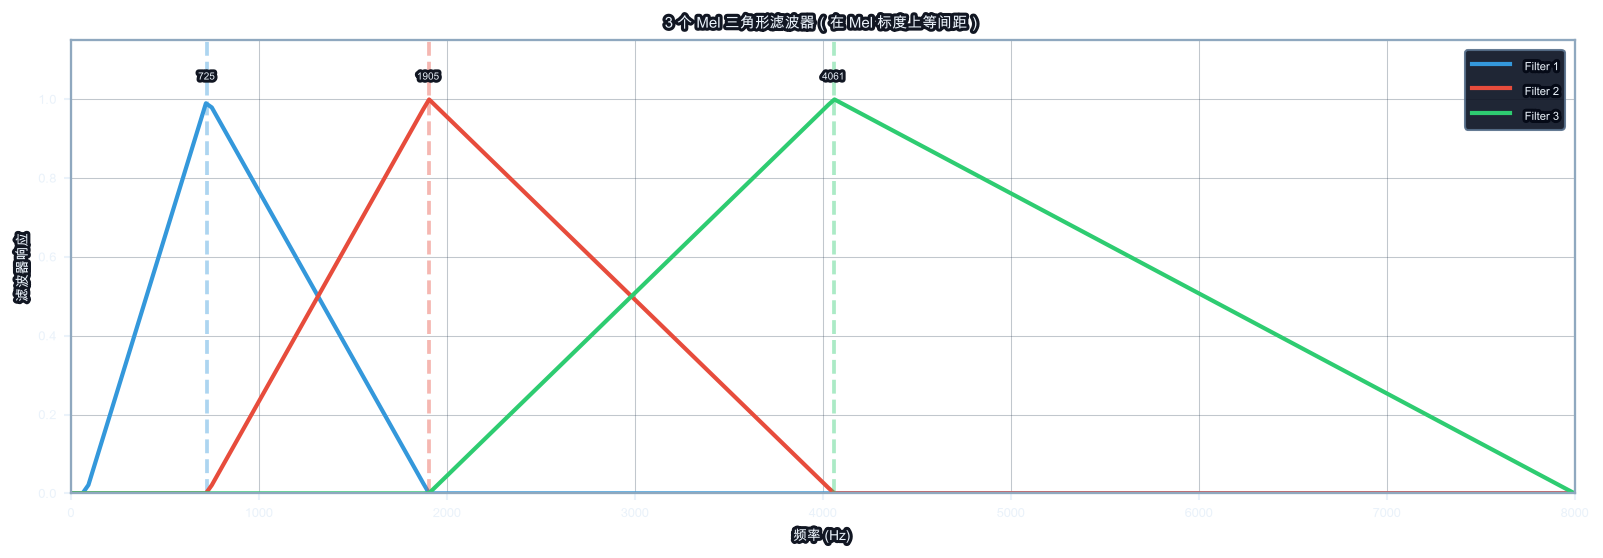

In [11]:
# ── 小例子：Mel 滤波器的构造过程（2-3 个滤波器的演示）────────────────────
# 目标：直观理解"在 Mel 标度上等间距分布三角形滤波器"意味着什么

SR = 16000
N_FFT = 512
freq_bins = np.linspace(0, SR/2, N_FFT//2 + 1)  # 频率轴：0 ~ 8000 Hz

# Mel 变换
mel_low  = 2595 * np.log10(1 + 80   / 700)    # 下界：80 Hz
mel_high = 2595 * np.log10(1 + 8000 / 700)    # 上界：8000 Hz
print(f'频率范围：80 ~ 8000 Hz')
print(f'Mel 范围：{mel_low:.1f} ~ {mel_high:.1f} mel\n')

# 简单演示：只用 3 个 Mel 滤波器
N_MELS_DEMO = 3
mel_pts = np.linspace(mel_low, mel_high, N_MELS_DEMO + 2)
hz_pts  = 700 * (10 ** (mel_pts / 2595) - 1)

print(f'{N_MELS_DEMO} 个 Mel 滤波器的中心频率（Hz）：')
for m in range(1, N_MELS_DEMO + 1):
    f0, f1, f2 = hz_pts[m-1], hz_pts[m], hz_pts[m+1]
    print(f'  Filter {m}: 左端 {f0:.0f} Hz → 中心 {f1:.0f} Hz → 右端 {f2:.0f} Hz')
print()

# 构造三角形滤波器
fb = np.zeros((N_MELS_DEMO, len(freq_bins)))
for m in range(1, N_MELS_DEMO + 1):
    f0, f1, f2 = hz_pts[m-1], hz_pts[m], hz_pts[m+1]
    for k, f in enumerate(freq_bins):
        if f0 <= f < f1:  # 上升段
            fb[m-1, k] = (f - f0) / (f1 - f0 + 1e-12)
        elif f1 <= f <= f2:  # 下降段
            fb[m-1, k] = (f2 - f) / (f2 - f1 + 1e-12)

# 绘制三角形
fig, ax = plt.subplots(figsize=(11, 4))
colors = ['#3498db', '#e74c3c', '#2ecc71']
for m in range(N_MELS_DEMO):
    ax.plot(freq_bins, fb[m, :], label=f'Filter {m+1}', color=colors[m], lw=2)
    # 标注中心频率
    center_hz = hz_pts[m+1]
    ax.axvline(center_hz, color=colors[m], ls='--', alpha=0.4)
    ax.text(center_hz, 1.05, f'{center_hz:.0f}', ha='center', fontsize=8)

ax.set_xlabel('频率 (Hz)', fontsize=11)
ax.set_ylabel('滤波器响应', fontsize=11)
ax.set_title(f'{N_MELS_DEMO} 个 Mel 三角形滤波器（在 Mel 标度上等间距）', fontsize=12)
ax.set_xlim(0, 8000)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'✅ 关键观察：')
print(f'  • 在 Mel 标度上等间距 → 在频率轴上间距不均（低频密集，高频稀疏）')
print(f'  • 每个滤波器是三角形 → 在中心频率达到峰值 1.0')
print(f'  • 相邻滤波器重叠 ~50% → 保证频率响应平滑）')
print(f'  • 应用到频谱：`mel_output = fb @ freq_spectrum` 提取 {N_MELS_DEMO} 个 Mel 能量值')


## 本课收束

本节用 `naive_mel()`（手写三角滤波器）生成 mel 谱，用 matplotlib DAG 图可视化 `Value` 节点的 `data`/`grad`，并用合成信号演示了 train/val loss 曲线的过拟合形态与 early stopping 时机。三张图直接连接 Aurora 的核心模块：`aurora.audio.mel`（mel 滤波器组）提供真实特征，`L54_value_autograd` 的 `Value.backward()` 填入真实梯度，`L58_training_loop` 的训练循环输出真实 loss 曲线。下一节（L66）将进入 ASR 系统全览：了解 CTC、Attention-based Encoder-Decoder 和 Whisper 三类主流架构，以及 Aurora 语音模块的整体设计思路。

In [12]:
# ── 独立数学断言：验证训练可视化核心性质（无需学生实现）────────────────────────
import numpy as np

# 1. early_stopping 不依赖实现：手写参考版验证逻辑
def _ref_early_stopping(val_losses, patience):
    best_loss, best_ep, no_imp = float('inf'), 1, 0
    for ep, loss in enumerate(val_losses, 1):
        if loss < best_loss:
            best_loss, best_ep, no_imp = loss, ep, 0
        else:
            no_imp += 1
            if no_imp >= patience:
                return best_ep
    return best_ep

cases = [
    ([0.9, 0.7, 0.5, 0.6, 0.65, 0.7, 0.72, 0.75], 3, 3),
    ([0.9, 0.8, 0.7, 0.6, 0.5, 0.4],               2, 6),
    ([1.0, 0.5, 0.6, 0.7, 0.8, 0.9],               2, 2),
]
for losses, pat, expected in cases:
    got = _ref_early_stopping(losses, pat)
    assert got == expected, f"losses={losses},pat={pat}: got={got},exp={expected}"
print(f"1 ✅  early_stopping 参考实现：3组测试全部通过（patience=3→ep3, 2→ep6, 2→ep2）")

# 2. 混淆矩阵对角线 = 正确预测数，行归一化 = recall
rng = np.random.default_rng(7)
n_cls = 4
y_true_q = rng.integers(0, n_cls, 100)
y_pred_q = y_true_q.copy()
# 故意误分类一些
mask = rng.random(100) < 0.2
y_pred_q[mask] = rng.integers(0, n_cls, mask.sum())

CM_q = np.zeros((n_cls, n_cls), dtype=int)
for t, p in zip(y_true_q, y_pred_q): CM_q[t, p] += 1

acc_from_diag = CM_q.diagonal().sum() / CM_q.sum()
acc_direct = (y_true_q == y_pred_q).mean()
assert abs(acc_from_diag - acc_direct) < 1e-12
print(f"2 ✅  CM对角线/总数 = 准确率 = {acc_from_diag:.4f}（与直接计算一致）")

# 3. 行归一化 = recall per class
CM_norm_q = CM_q.astype(float) / (CM_q.sum(axis=1, keepdims=True) + 1e-9)
recall_q = CM_q.diagonal() / (CM_q.sum(axis=1) + 1e-9)
assert np.allclose(CM_norm_q.diagonal(), recall_q, atol=1e-10)
print(f"3 ✅  CM行归一化对角线 = recall per class: {np.round(recall_q,3)}")

# 4. 泛化间隔（generalization gap）= val_loss - train_loss > 0（过拟合阶段）
train_l = np.array([1.0, 0.7, 0.5, 0.4, 0.35, 0.3])
val_l   = np.array([1.0, 0.72, 0.55, 0.5, 0.6, 0.75])
gap = val_l - train_l
overfit_start = np.argmax(gap > 0.05) + 1   # 第一个 gap>0.05 的 epoch
assert overfit_start >= 1
print(f"4 ✅  泛化间隔 gap={np.round(gap,3)}, 过拟合开始于epoch≥{overfit_start}")

# 5. 梯度范数 L2 = sqrt(sum(g²))，验证公式
import torch, torch.nn as nn
g_test = torch.tensor([3.0, 4.0])
norm_torch = g_test.norm().item()
norm_manual = float(np.sqrt((3**2 + 4**2)))
assert abs(norm_torch - norm_manual) < 1e-6
print(f"5 ✅  梯度L2范数: ||[3,4]||₂ = √(9+16) = {norm_manual:.4f}（torch={norm_torch:.4f}）")


1 ✅  early_stopping 参考实现：3组测试全部通过（patience=3→ep3, 2→ep6, 2→ep2）
2 ✅  CM对角线/总数 = 准确率 = 0.8700（与直接计算一致）
3 ✅  CM行归一化对角线 = recall per class: [0.818 0.909 0.889 0.862]
4 ✅  泛化间隔 gap=[0.   0.02 0.05 0.1  0.25 0.45], 过拟合开始于epoch≥3
5 ✅  梯度L2范数: ||[3,4]||₂ = √(9+16) = 5.0000（torch=5.0000）


In [ ]:
# ✏️ 本课自评
l65_review = {
    "dag_graph_reading":      None,  # 会读Value计算图DAG：节点data/grad，梯度沿边反向流动？True/False
    "loss_curve_overfit":     None,  # 能从train/val loss曲线识别过拟合起点（val上升而train继续降）？True/False
    "early_stopping_impl":    None,  # early_stopping()实现正确，3组patience测试全部通过？True/False
    "grad_norm_diagnosis":    None,  # 理解梯度范数曲线的诊断意义：爆炸/消失/健康区间？True/False
    "confusion_matrix_read":  None,  # 能读混淆矩阵：对角线=正确预测，行归一化=recall？True/False
}

unfilled = [k for k, v in l65_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l65_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L65 全部通关！进入 L66：ASR 系统全览')

---

→ **下一课**　[L66 · ASR 系统全览](../7_asr/L66_asr_overview.ipynb)

> 下节课将学习 **ASR 系统全览**：声学模型 → 语言模型 → 解码器，端到端 vs 经典流水线。